## FINANCIAL INCLUSION IN AFRICA

### OBJECTIVES:
1) The objective of this project is to create a machine learning model to predict which individuals are most likely to have or use a bank account. The models and solutions developed can provide an indication of the state of financial inclusion in Kenya, Rwanda, Tanzania and Uganda, while providing insights into some of the key factors driving individual's financial security. 

2) Secondly, Conduct analysis and derive meaningful insights that can help policymakers, NGOs, and businesses develop targeted strategies to improve financial access and economic growth. To achieve this goal, will be performing the following analysis:

    1.Analyzing the distribution of respondents by country, age, gender, location, etc over the Years.

    2.⁠calculating the percentage of individuals with and without bank accounts in each country 

    3.identifying correlations between bank account ownership and other features.

3) Model Selection and Evaluation: Train and evaluate different machine learning models to predict bank account ownership and use scoring metrics to evaluate the performance of your models.

A survey was conducted and various information were collected from over 20,000 individuaks from four (4) countries across Africa including Uganda, Rwanda, Kenya and Tanzania. The information relates to features that indicates whether an individual is likely to own a bank account or not.

The following steps will be taken:

1. Loading the file into a pandas dataframe and making a copy of dataset
2. Understanding the data, its features and samples
3. Data preprocessing
4. Data wrangling
5. Analyzing the data
6. Building a model

## Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset and making a copy of dataset to preserve its original file

In [2]:
df_Test = pd.read_csv(r"C:\Users\Lenovo\Documents\Promise2025\Test.csv")
df_Train = pd.read_csv(r"C:\Users\Lenovo\Documents\Promise2025\Train.csv")

df = df_Train.copy()
df2 = df_Test.copy()
df.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [3]:
df2.head()

,country,year,uniqueid,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_6056,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government
1,Kenya,2018,uniqueid_6060,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private
2,Kenya,2018,uniqueid_6065,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent
3,Kenya,2018,uniqueid_6072,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent
4,Kenya,2018,uniqueid_6073,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent


## Understanding the data, its features and samples

In [4]:
df.shape

(23524, 13)

The dataset consist of 23,524 observations with 13 features;

1	country: Country which interviewee is in.

2	year: Year survey was done.

3	uniqueid : Unique identifier for each interviewee

4	location_type: Rural, Urban

5	cellphone_access: If interviewee has access to a cellphone

6	household_size: Number of people living in one house

7	age_of_respondent: The age of the interviewee

8	gender_of_respondent: Gender of interviewee

9	relationship_with_head: The interviewee’s relationship with the head of the house

10	marital_status: The martial status of the interviewee

11	education_level: Highest level of education of the interviewee

12	job_type: job type of the interviewee

13 bank_account: if an interviewee has a bank account or not

In [5]:
df.columns

Index(['country', 'year', 'uniqueid', 'bank_account', 'location_type',
       'cellphone_access', 'household_size', 'age_of_respondent',
       'gender_of_respondent', 'relationship_with_head', 'marital_status',
       'education_level', 'job_type'],
      dtype='object')

retrieved the column names of our DataFrame, helping one to understand the dataset's structure, ensuring that the features are correctly named or formatted.

## check for informations contained in the dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


The above summaries reveals that the dataset has 13 features, including a Year feature stored as an integer. This comfirms the presence of 3 interger features (including Year) and 9 object features, with no missing values in any features.

## Checking for duplicates

In [7]:
df.duplicated().sum()

0

Above informations shows there's no duplicates in the dataset

## Checking for missing values

In [8]:
df.isna().sum()

country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64

No missing values in any of the features, ensuring data completeness

### Checking for unique values in each feature to help understand the diversity on the data, particularly for numeric feature like Year and categorical features.

In [9]:
for col in df.select_dtypes('object'):
    print(df[col].value_counts())
    print(':' + '-'*10)

country
Rwanda      8735
Tanzania    6620
Kenya       6068
Uganda      2101
Name: count, dtype: int64
:----------
uniqueid
uniqueid_1       4
uniqueid_1413    4
uniqueid_1411    4
uniqueid_1410    4
uniqueid_1409    4
                ..
uniqueid_7318    1
uniqueid_7317    1
uniqueid_7316    1
uniqueid_7315    1
uniqueid_8759    1
Name: count, Length: 8735, dtype: int64
:----------
bank_account
No     20212
Yes     3312
Name: count, dtype: int64
:----------
location_type
Rural    14343
Urban     9181
Name: count, dtype: int64
:----------
cellphone_access
Yes    17454
No      6070
Name: count, dtype: int64
:----------
gender_of_respondent
Female    13877
Male       9647
Name: count, dtype: int64
:----------
relationship_with_head
Head of Household      12831
Spouse                  6520
Child                   2229
Parent                  1086
Other relative           668
Other non-relatives      190
Name: count, dtype: int64
:----------
marital_status
Married/Living together    10749
Si


The code loops through each categorical (object-type) features in the DataFrame and prints the frequency count of unique values for each features, providing a clear view of the distribution of categorical data across all relevant features.

### The Unique_id feature will be dropped cause it only serves as a unique identifier for each respondent as it is not relevant in predicting wether an individual is likely to have a bank account or not.

In [10]:
df.drop(columns=['uniqueid'], inplace=True)
df2.drop(columns=['uniqueid'], inplace=True)

## Checking for the discriptive statistics of the numerical features

In [11]:
df.describe()

,year,household_size,age_of_respondent
count,23524.000000,23524.000000,23524.000000
mean,2016.975939,3.797483,38.805220
std,0.847371,2.227613,16.520569
min,2016.000000,1.000000,16.000000
25%,2016.000000,2.000000,26.000000
50%,2017.000000,3.000000,35.000000
75%,2018.000000,5.000000,49.000000
max,2018.000000,21.000000,100.000000


Since the numerical features have varying scales, normalization will be applied to speed up model convergence, balance the influence of all features, and enhance generalization to unseen data, minimizing the risk of overfitting.

### Checking for outliers in the numerical features, excluding the year feature

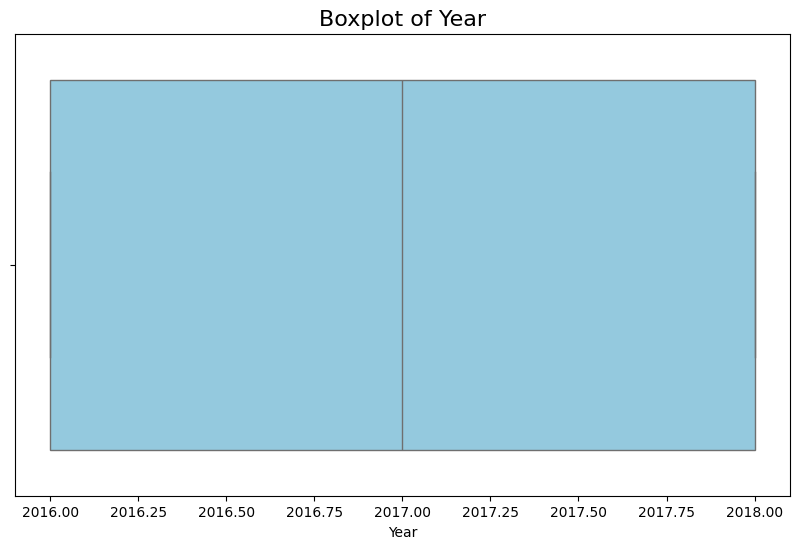

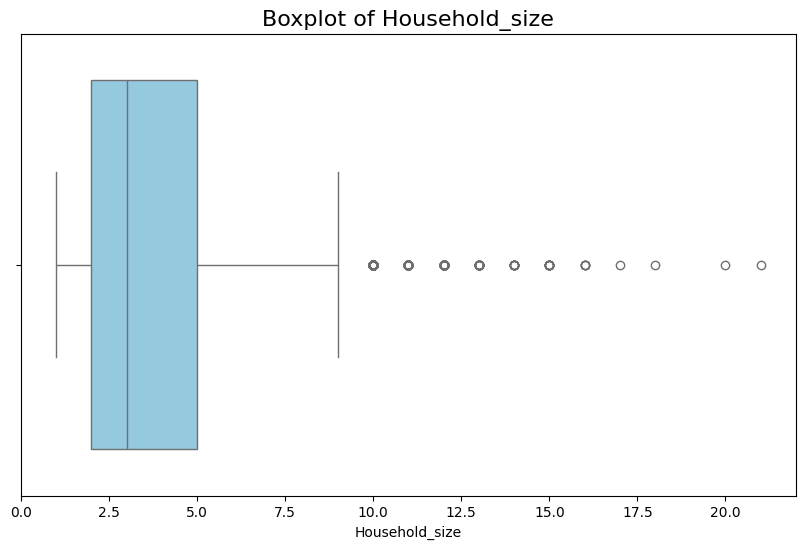

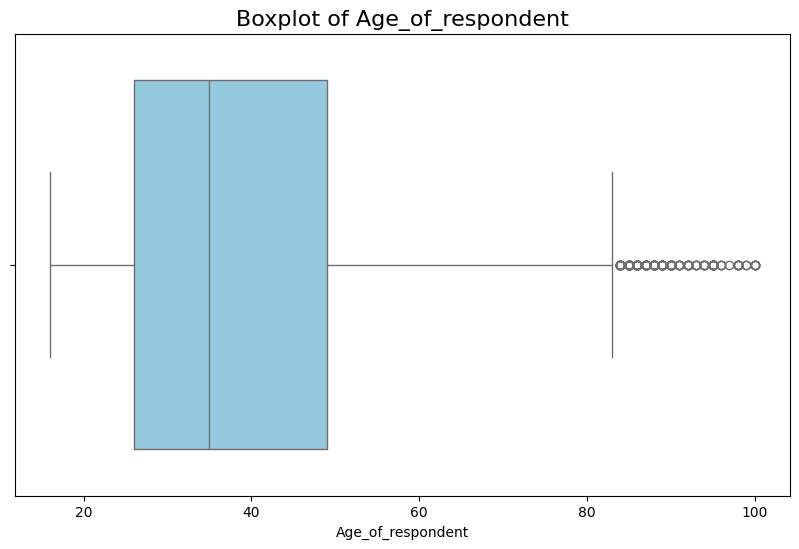

In [12]:

numerical_cols = [col for col in df.select_dtypes(include=['int64', 'float64'])] #.columns if col != 'year']

# Creating boxplots for numerical features
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=col, color="skyblue")
    plt.title(f"Boxplot of {col.capitalize()}", fontsize=16)
    plt.xlabel(col.capitalize())
    plt.show()


The outliers present in the household_size feature (e.g., household sizes > 10) were analyzed and deemed genuine because they represent realistic values in specific contexts, such as larger families or shared housing. Same applies for age_of_respondent feature, as they represent realistic variations in the age distribution of respondents.

## Analyzing the outliers using the interquartile range, out-putting the upper and lower limit and thier percentages

In [13]:
for col in df.columns:
    if df[col].dtype != 'object':
       q3, q1 = np.percentile(df[col], [75,25])
       iqr = q3 - q1
       UL = q3 + 1.5 * iqr
       LL = q1 - 1.5 * iqr
       
       Totaloutliers = len(df.loc[df[col] < LL, col]) + len(df.loc[df[col] > UL, col])
       print(Totaloutliers)

       percent = (Totaloutliers / len(df.index)) * 100
       print(f"percentage of outliers for {col} is {percent}")
       print('upper limit:', UL)
       print('lower limit:', LL)
       print('---------------------')
       

0
percentage of outliers for year is 0.0
upper limit: 2021.0
lower limit: 2013.0
---------------------
381
percentage of outliers for household_size is 1.619622513178031
upper limit: 9.5
lower limit: -2.5
---------------------
241
percentage of outliers for age_of_respondent is 1.02448563169529
upper limit: 83.5
lower limit: -8.5
---------------------


## Analysis

 ### 1.Analyzing the distribution of respondents by gender_of_respondent, marital_status, location_type, bank_account, cellphone_access, education_level, job_type, relationship_with_head over the Years.

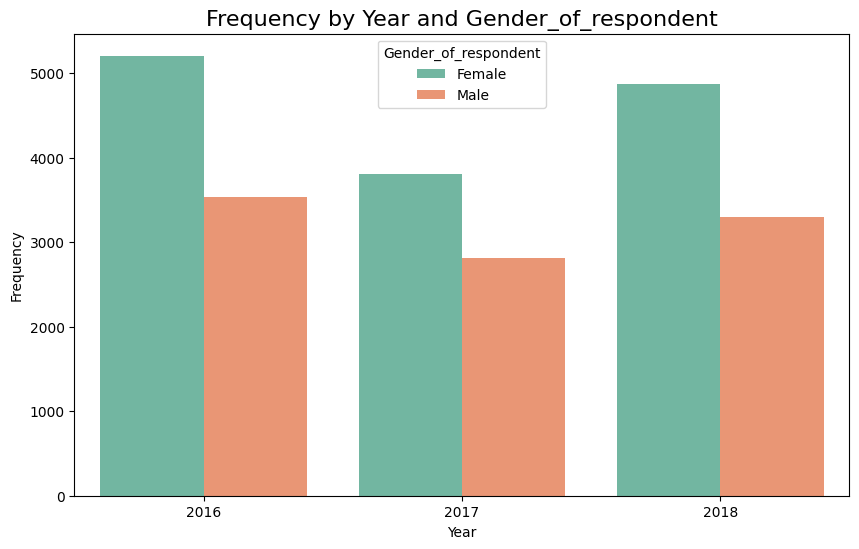

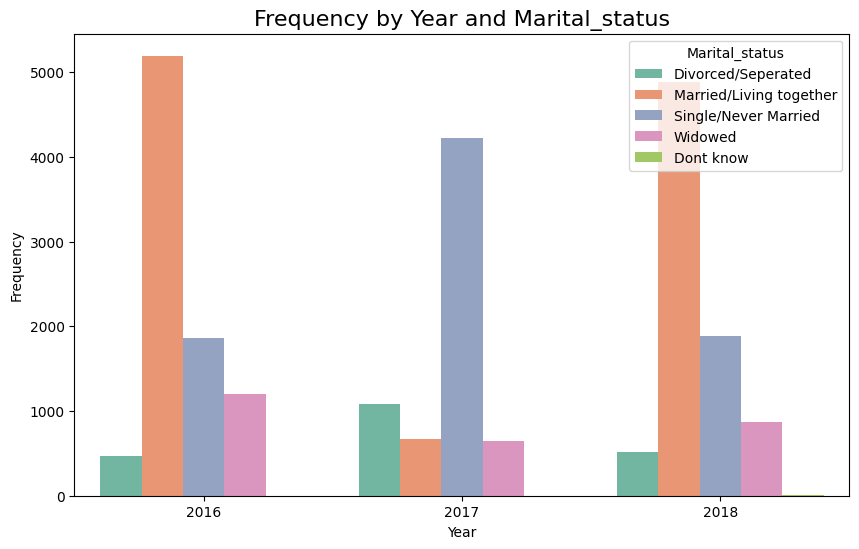

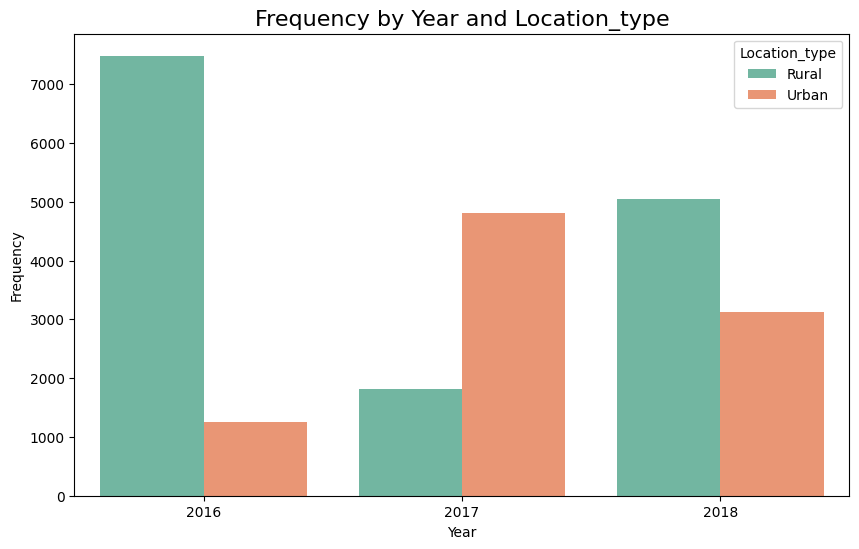

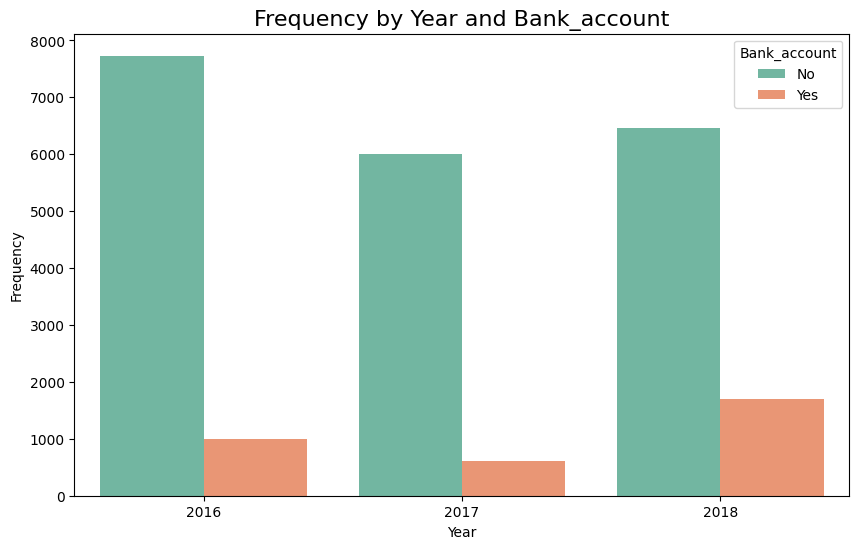

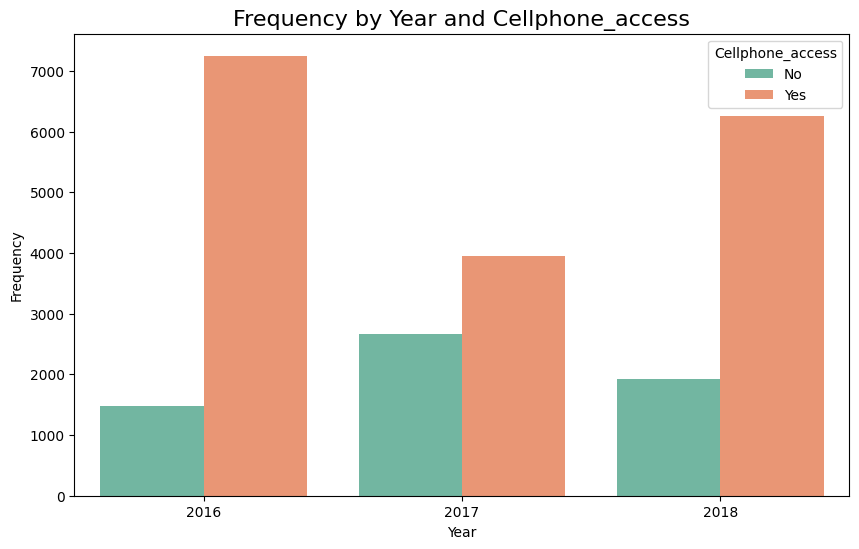

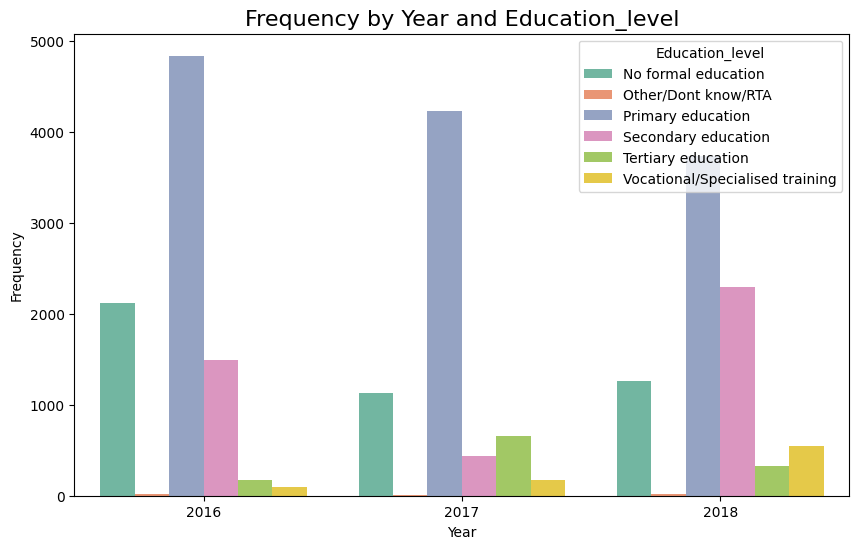

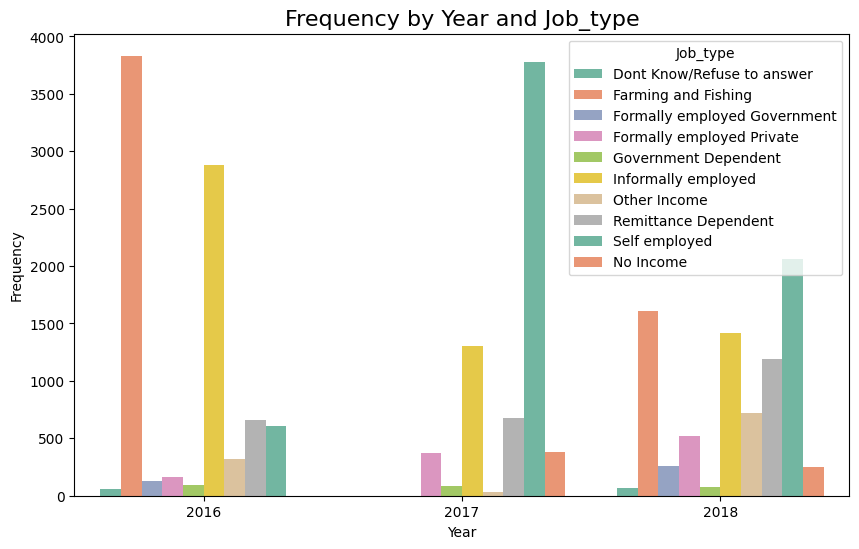

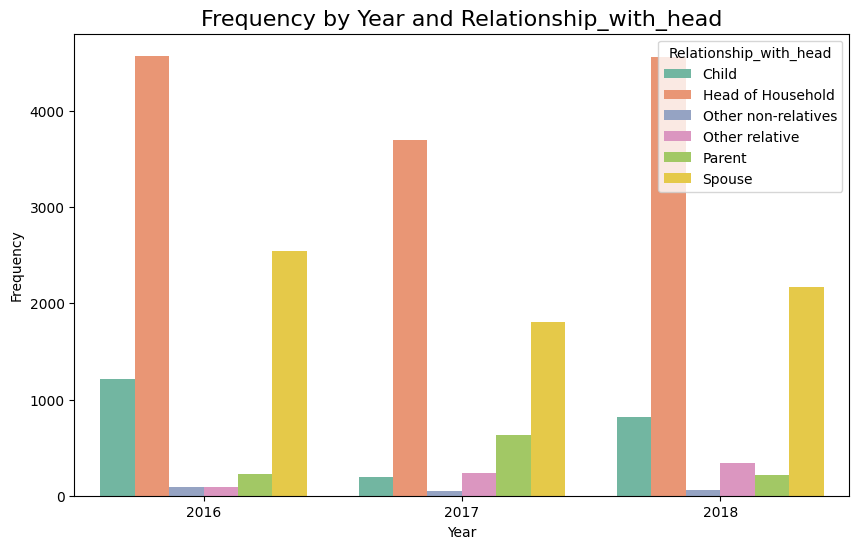

In [15]:
hist_cols = ['gender_of_respondent', 'marital_status', 'location_type', 'bank_account','cellphone_access', 'education_level', 'job_type', 'relationship_with_head']
for col in hist_cols:
    plt.figure(figsize=(10, 6))
    data_grouped = df.groupby(['year', col]).size().reset_index(name='frequency')
    sns.barplot(data=data_grouped, x='year', y='frequency', hue=col, palette="Set2")
    plt.title(f"Frequency by Year and {col.capitalize()}", fontsize=16)
    plt.ylabel('Frequency')
    plt.xlabel('Year')
    plt.legend(title=col.capitalize())
    plt.show()

### Obervations:
. Gender: The visualizations provide insights into demographic distribution of respondents by gender over the years, revealing consistent trends, such as higher participation from females across the years.

. Marital Status: The marital status distribution varies slightly across years, with Married/Living Together and Single/Never Married consistently being the most prominent.

. Location Type: The graph shows how the distribution of the variable being measured changed from being predominantly rural in 2016 to being more evenly distributed between rural and urban sectors by 2018. A possible turning point or influencing factor during that time period is suggested by the notable changes that occurred between 2016 and 2017.

. Bank Account: In 2016, the highest frequency of respondents without a bank account is observed, with those owning a bank account being minimal, in 2017, the total frequency decreases compared to 2016, but the proportion of bank account ownership remains consistent. In 2018, the frequency increases again compared to 2017, but the distribution between those with and without bank accounts remains similar to previous years. This suggests that access to bank accounts has consistently remained limited over the years for the respondents.

. Cellphone_access: From 2016 to 2018, the frequency of cellular access (yes/no) is displayed in this chart. "Yes" (having a cellphone) is constantly far more common than "No" in every year. The number of "Yes" responses increased slightly between 2016 and 2017 and more significantly between 2017 and 2018. On the other hand, "No" indicates a decline over time.

. Education_level: The frequency of various educational levels—no formal education, primary, secondary, tertiary, etc.—from 2016 to 2018 is shown in this chart. The most common type of schooling is primary, then secondary. All of the categories show variations over time, which could indicate shifts in reporting or educational achievement.

. job_type: The job type frequencies from 2016 to 2018 are displayed in this chart. "Self Employed" and "Farming and Fishing" are consistently the most popular. While "No Income" and informal employment decline, formal employment rises. Variations over time point to shifting economic circumstances.

. relationship_with_head: From 2016 to 2018, the frequency of various household relationships (such as spouse, kid, and head of household) is displayed in this chart. It is always "Head of Household" that appears most frequently. For the majority of categories, there are variations from year to year, indicating modifications in reporting or household configurations.

### 2.⁠calculating the percentage of individuals with and without bank accounts in each country

In [16]:
account_count = df.groupby(['country', 'bank_account']).size().reset_index(name='count')

total_count = account_count.groupby('country')['count'].sum().reset_index(name='total')

merged = account_count.merge(total_count, on='country')

merged['percentage'] = (merged['count'] / merged['total']) * 100

merged_percentage = merged[['country', 'bank_account', 'percentage']]
#display each bank account percentages

In [17]:
merged_percentage

,country,bank_account,percentage
0,Kenya,No,74.934080
1,Kenya,Yes,25.065920
2,Rwanda,No,88.517459
3,Rwanda,Yes,11.482541
4,Tanzania,No,90.830816
5,Tanzania,Yes,9.169184
6,Uganda,No,91.385055
7,Uganda,Yes,8.614945



The code calculates the percentage of individuals with and without a bank account in each country. It groups the data by country and bank account status, determines the total count per country, merges the counts, and calculates the percentage for each bank account status relative to the total. The result displays the country, bank account status, and the corresponding percentage.

In [18]:
merged_percentage

,country,bank_account,percentage
0,Kenya,No,74.934080
1,Kenya,Yes,25.065920
2,Rwanda,No,88.517459
3,Rwanda,Yes,11.482541
4,Tanzania,No,90.830816
5,Tanzania,Yes,9.169184
6,Uganda,No,91.385055
7,Uganda,Yes,8.614945


The data shows the percentage distribution of individuals with and without a bank account across four countries: Kenya, Rwanda, Tanzania, and Uganda. The percentage column representing the proportion of respondents in each country who have or do not have a bank account.

Kenya: 74.93% of individuals do not have a bank account, while 25.07% do.
Rwanda: 88.52% are without a bank account, while 11.48% have one.
Tanzania: 90.83% lack a bank account, with only 9.17% having one.
Uganda: 91.39% do not have a bank account, and 8.61% have one.

A significant majority of the population in all four countries is unbanked, with the highest percentage of unbanked individuals in Uganda (91.39%) and the lowest in Kenya (74.93%).
The data highlights the challenges in financial inclusion across these countries, indicating a potential opportunity for initiatives aimed at increasing access to banking services, especially in Tanzania, Uganda, and Rwanda.

## 3) identifying correlations between bank account ownership and other features such as education level, job type, and household size.

- To comfirm if there's a relationship(correlation) between the features, we will be Encoding Categorical Features
- Features like location_type, cellphone_access, and gender_of_respondentthe labelEncoder will be used while for other features, OneHotEncoder will be used

In [19]:
df_coded_corr = df.copy()
df_test_coded_corr = df2.copy()

In [20]:
#pip install -U scikit-learn category-encoders

In [21]:
#!pip install category-encoders

In [22]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
import category_encoders as ce

In [23]:
# Label Encoder conversion
le = LabelEncoder()
df_coded_corr['location_type'] = le.fit_transform(df_coded_corr['location_type'])
df_coded_corr['cellphone_access'] = le.fit_transform(df_coded_corr['cellphone_access'])
df_coded_corr['gender_of_respondent'] = le.fit_transform(df_coded_corr['gender_of_respondent'])
df_coded_corr['bank_account'] = le.fit_transform(df_coded_corr['bank_account'])

In [24]:
# categorical features to be converted to OneHotEncoder using pd.get_dummies
df_coded_corr = pd.get_dummies(df_coded_corr, columns=['relationship_with_head', 'marital_status', 'education_level', 'job_type', 'country'], drop_first=True).astype(int)

In [25]:
df_coded_corr.head()

,year,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head_Head of Household,relationship_with_head_Other non-relatives,relationship_with_head_Other relative,...,job_type_Formally employed Private,job_type_Government Dependent,job_type_Informally employed,job_type_No Income,job_type_Other Income,job_type_Remittance Dependent,job_type_Self employed,country_Rwanda,country_Tanzania,country_Uganda
0,2018,1,0,1,3,24,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,2018,0,0,0,5,70,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
2,2018,1,1,1,5,26,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,2018,0,0,1,5,34,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
4,2018,0,1,0,8,26,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [26]:
df_coded_corr.describe()

,year,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head_Head of Household,relationship_with_head_Other non-relatives,relationship_with_head_Other relative,...,job_type_Formally employed Private,job_type_Government Dependent,job_type_Informally employed,job_type_No Income,job_type_Other Income,job_type_Remittance Dependent,job_type_Self employed,country_Rwanda,country_Tanzania,country_Uganda
count,23524.000000,23524.000000,23524.000000,23524.000000,23524.000000,23524.000000,23524.000000,23524.000000,23524.000000,23524.000000,...,23524.000000,23524.000000,23524.000000,23524.000000,23524.000000,23524.000000,23524.000000,23524.000000,23524.000000,23524.000000
mean,2016.975939,0.140792,0.390282,0.741966,3.797483,38.805220,0.410092,0.545443,0.008077,0.028397,...,0.044848,0.010500,0.237927,0.026654,0.045911,0.107422,0.273635,0.371323,0.281415,0.089313
std,0.847371,0.347815,0.487824,0.437562,2.227613,16.520569,0.491861,0.497941,0.089510,0.166106,...,0.206974,0.101932,0.425823,0.161072,0.209296,0.309656,0.445834,0.483169,0.449699,0.285201
min,2016.000000,0.000000,0.000000,0.000000,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,0.000000,0.000000,0.000000,2.000000,26.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2017.000000,0.000000,0.000000,1.000000,3.000000,35.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2018.000000,0.000000,1.000000,1.000000,5.000000,49.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
max,2018.000000,1.000000,1.000000,1.000000,21.000000,100.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [27]:
df_corr = df_coded_corr.corr()
df_corr.head()

,year,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head_Head of Household,relationship_with_head_Other non-relatives,relationship_with_head_Other relative,...,job_type_Formally employed Private,job_type_Government Dependent,job_type_Informally employed,job_type_No Income,job_type_Other Income,job_type_Remittance Dependent,job_type_Self employed,country_Rwanda,country_Tanzania,country_Uganda
year,1.000000,0.112318,0.214621,-0.066505,-0.052264,-0.019330,0.000317,0.029492,-0.013692,0.081872,...,0.094141,-0.006426,-0.156028,0.081631,0.101870,0.095070,0.180932,-0.885158,0.017770,0.378473
bank_account,0.112318,1.000000,0.087288,0.209669,-0.028326,0.019429,0.117234,0.114506,-0.009218,-0.020639,...,0.249478,0.018255,-0.098456,-0.057121,0.025663,-0.045701,-0.015978,-0.057378,-0.088345,-0.049200
location_type,0.214621,0.087288,1.000000,-0.085238,-0.257284,-0.047373,0.012924,0.017202,0.031979,0.028483,...,0.067894,-0.002052,-0.071098,0.045064,0.011032,0.054247,0.296278,-0.389062,0.431626,-0.069356
cellphone_access,-0.066505,0.209669,-0.085238,1.000000,0.091360,-0.103611,0.102370,0.055966,0.023908,-0.030200,...,0.105723,-0.058395,-0.008392,-0.103875,-0.006649,-0.083128,-0.056012,0.154415,-0.206499,-0.032318
household_size,-0.052264,-0.028326,-0.257284,0.091360,1.000000,-0.129729,0.014576,-0.264926,0.026966,0.027031,...,-0.069462,-0.044929,0.007999,-0.019907,0.054045,0.014530,-0.150520,0.235996,-0.408641,0.167451


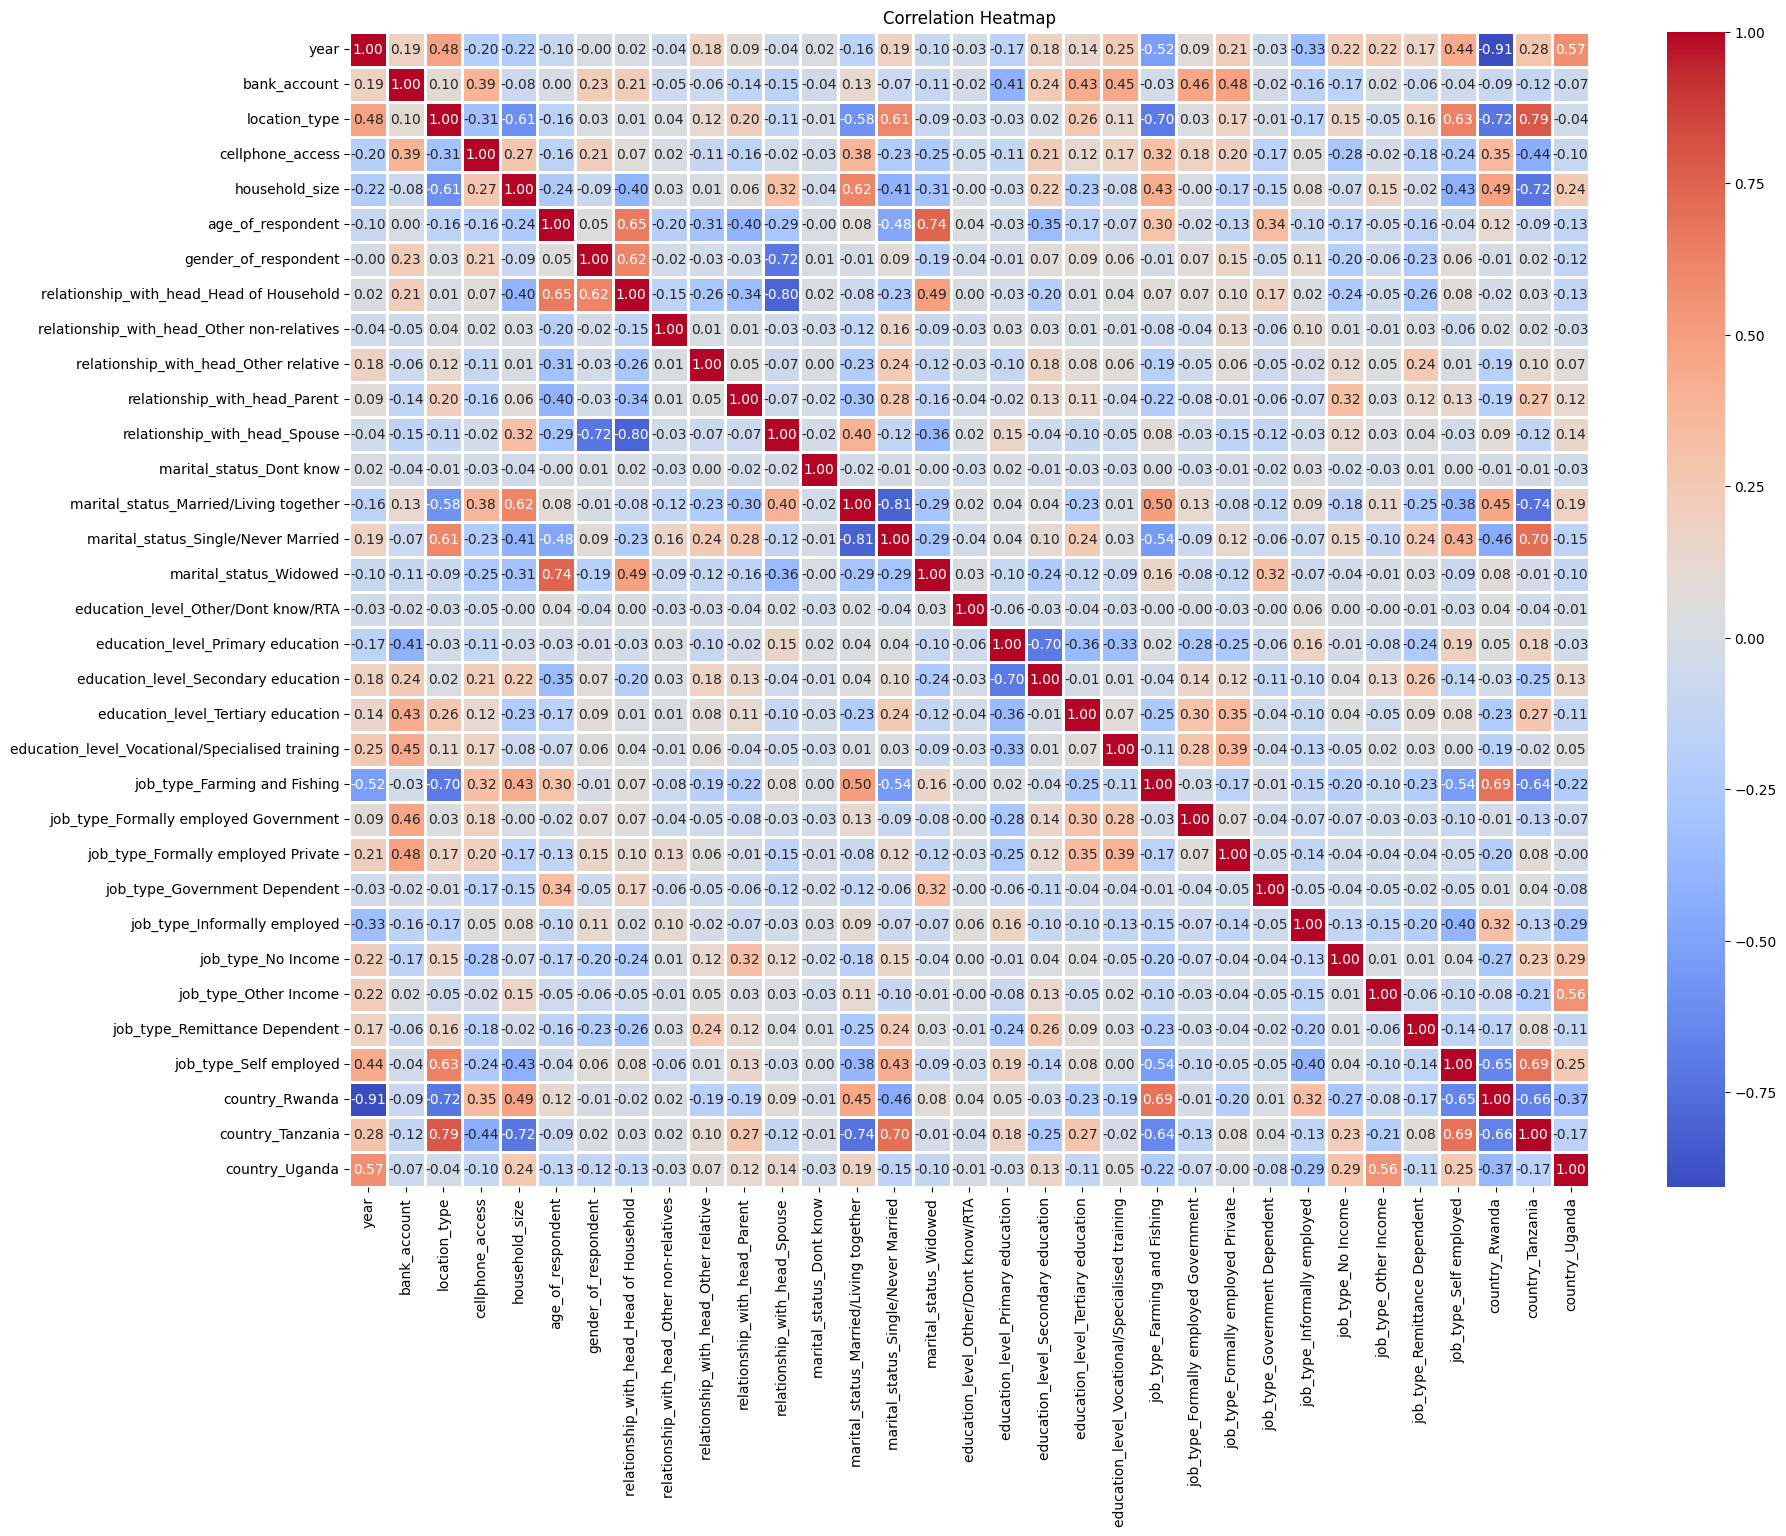

In [28]:
plt.figure(figsize=(20,15))
sns.heatmap(df_corr.corr(), cmap='coolwarm', fmt='.2f', linewidths=2, annot=True)
plt.title('Correlation Heatmap')

plt.show()

Key oberservations from the heatmap:

1. Having a bank account and being from Kenya are strongly positively correlated.whereas bank account ownership is negatively correlated in Rwanda, Tanzania, and Uganda. 

2. Compared to people in rural areas, persons living in metropolitan areas are much more likely to have a bank account. 

3. Bank account ownership and cellphone access are positively correlated, indicating that mobile technology contributes to financial inclusion. 

4. Those who are widowed or single (never married) have a negative link with bank account ownership, but married or cohabiting people are more likely to have one. 

5. There is a small positive association between holding a bank account and being female, which may be due to the dataset's greater proportion of female respondents.

key Insights: 

1. Influence of Country-Specific elements: Cultural norms, financial infrastructure, and economic growth are among the elements that are shown to have a major impact on the variations in bank account ownership among nations. Kenya's higher banking penetration is probably a result of its robust financial sector, pro-financial inclusion legislation (such laws governing mobile money and financial literacy initiatives), and higher rates of urbanization. On the other hand, previous political unrest, economic circumstances, and the growth of the banking sector in Rwanda, Tanzania, and Uganda may all have an impact on the unfavorable correlations shown there. 

2. Given that urban areas often have superior banking infrastructure than rural ones, the significant association between bank account ownership and urban residency emphasizes the significance of having physical access to financial institutions. 

3. The positive relationship between bank account ownership and mobile phone access indicates that digital financial services and mobile banking are essential for increasing financial access. 

4. The relationship between job type and bank account ownership highlights the importance of employment status and income stability on financial access, as people in formal employment (private sector, self-employed) are more likely to own a bank account. 

While these correlations show relationships, they do not prove causality. Disparities in financial inclusion could be caused by additional underlying causes. Although this study offers insightful information about banking patterns in Kenya, Rwanda, Tanzania, and Uganda, more investigation is required to fully comprehend the dynamics of financial inclusion.


## Splitting the data in train and test set

In [29]:
df_encode = df.copy()
test_set = df2.copy()

In [30]:
from sklearn.model_selection import train_test_split

X =  df_encode.drop(columns= 'bank_account')
y = df_encode['bank_account']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size = 0.1, random_state=7)

In [31]:
split_df= [X_train, X_test, y_train, y_test]

for df in split_df:
    df.reset_index(drop= True, inplace= True)

## Encoding the target variable, fitting it and transforming

In [32]:
from sklearn.preprocessing import LabelEncoder

le= LabelEncoder()

le.fit(y_train)

y_train_coded= le.transform(y_train)
y_test_coded= le.transform(y_test)

y_train= pd.Series(y_train_coded)
y_test= pd.Series(y_test_coded)

## Encoding categorical features

In [33]:
le= LabelEncoder()

le.fit(X_train['location_type'])

X_train['location_type'] = le.transform(X_train['location_type'])
X_test['location_type'] = le.transform(X_test['location_type'])
test_set['location_type'] = le.transform(test_set['location_type'])

In [34]:
le.fit(X_train['cellphone_access'])

X_train['cellphone_access'] = le.transform(X_train['cellphone_access'])
X_test['cellphone_access'] = le.transform(X_test['cellphone_access'])
test_set['cellphone_access'] = le.transform(test_set['cellphone_access'])

In [35]:
le.fit(X_train['gender_of_respondent'])

X_train['gender_of_respondent'] = le.transform(X_train['gender_of_respondent'])
X_test['gender_of_respondent'] = le.transform(X_test['gender_of_respondent'])
test_set['gender_of_respondent'] = le.transform(test_set['gender_of_respondent'])

In [36]:
cat_feat = ['country', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']
coder = ce.OneHotEncoder(cols=cat_feat, handle_unknown= 'return_nan', return_df= True, use_cat_names= True)

coder.fit(X_train[cat_feat])

X_train_coded= coder.transform(X_train[cat_feat])
X_test_coded= coder.transform(X_test[cat_feat])
test_set_coded= coder.transform(test_set[cat_feat])

In [37]:
X_train= X_train.drop(columns=cat_feat)
X_val= X_test.drop(columns=cat_feat)
test_set= test_set.drop(columns=cat_feat)

X_train= pd.concat([X_train, X_train_coded], axis=1)
X_test= pd.concat([X_val, X_test_coded], axis=1)
test_set= pd.concat([test_set, test_set_coded], axis=1)

## Normalizing numerical features

### Normalizing the numerical features to enable us see how strongly the features are related to each other on a scale from -1 to 1.

In [38]:
from sklearn.preprocessing import Normalizer

num_feat= ['year', 'household_size', 'age_of_respondent']

normalizer= Normalizer()

normalizer.fit(X_train[num_feat])

X_train[num_feat]= normalizer.transform(X_train[num_feat])
X_test[num_feat]= normalizer.transform(X_test[num_feat])
test_set[num_feat]= normalizer.transform(test_set[num_feat])

In [39]:
#!pip install lightgbm

## Training the model with all features

In [40]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score

model = LGBMClassifier()

kfold = RepeatedStratifiedKFold(n_splits = 10,
                                n_repeats= 3,
                                random_state= 7)

score = cross_val_score(model, X_train, y_train, scoring= 'accuracy', cv= 10).mean() 

print('lightgbm:',1- score.mean())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2682, number of negative: 16371
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 19053, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.140765 -> initscore=-1.808949
[LightGBM] [Info] Start training from score -1.808949
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2683, number of negative: 16371
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005220 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_

In [41]:
score

0.8879123673058112

In [42]:
from sklearn.metrics import accuracy_score

seed = 7
fold = 10

model = LGBMClassifier()

model.fit(X_train, y_train)
yhat= model.predict(X_train)
accu_score= accuracy_score(y_train, yhat)

print('lightgbm:',1- accu_score)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2981, number of negative: 18190
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004869 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 21171, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.140806 -> initscore=-1.808613
[LightGBM] [Info] Start training from score -1.808613
lightgbm: 0.09659439799726044


## Evaluation

In [43]:
score = cross_val_score(model, X_test, y_test, scoring= 'accuracy', cv= 10) 

print('lgbm:',1- score.mean())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 298, number of negative: 1819
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000993 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 823
[LightGBM] [Info] Number of data points in the train set: 2117, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.140765 -> initscore=-1.808949
[LightGBM] [Info] Start training from score -1.808949
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 298, number of negative: 1819
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000395 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 824
[LightGBM] [Info] Number

In [44]:
y_predict= model.predict(X_test)

score= accuracy_score(y_test, y_predict)

print('lgbm:',1- score)

lgbm: 0.11092222694432641


In [45]:
importance = model.feature_importances_

feat_import= []
feature = []
importance_scr= []
for feats, imp in zip(X_train.columns, importance):
    feature.append(feats)
    importance_scr.append(imp)
    score_list= [feats, imp]
    feat_import.append(score_list)
import_score= pd.DataFrame(feat_import, columns=['features', 'scores']).sort_values(by= 'scores',ascending= False)

In [46]:
import_score

,features,scores
3,household_size,561
0,year,486
4,age_of_respondent,465
1,location_type,147
5,gender_of_respondent,97
7,country_Kenya,83
6,country_Tanzania,68
21,education_level_Primary education,63
29,job_type_Informally employed,61
2,cellphone_access,60


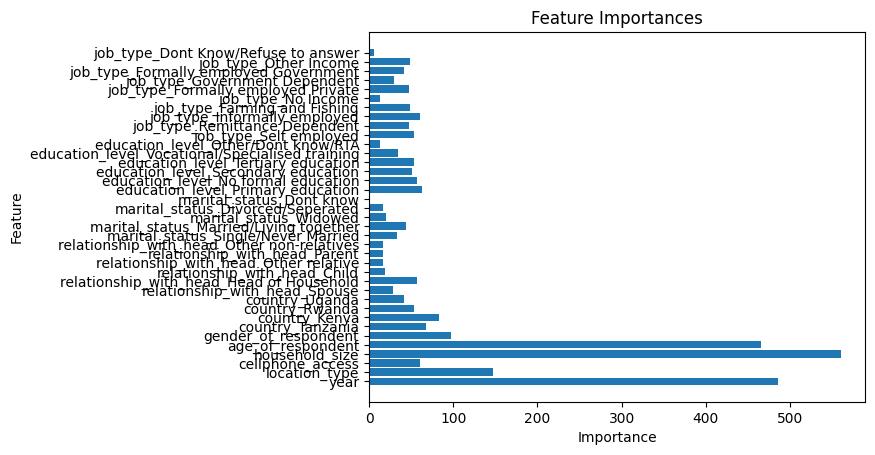

In [47]:
plt.barh(feature, importance_scr)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.show()

## Model Interpretation

From our model results, Key factors Driving Financial Inclusion:

Major Influencing Factors:

Household Size (561): The strongest predictor of financial inclusion. Larger households may have distinct financial needs, requiring more financial services or facing greater financial challenges.
Year (486): Financial inclusion changes significantly over time, influenced by policy shifts, technological advancements, and economic conditions.

Age of Respondent (465): Different age groups experience varying levels of financial access, with younger and older individuals potentially facing more barriers compared to middle-aged groups.

Demographic Impact:

Location Type (147): Urban and rural differences play a crucial role in access to financial services and infrastructure.
Gender of Respondent (97): While less influential than other factors, gender disparities in financial inclusion remain notable.

Socioeconomic Contributions:

Education Level (51–63): Higher education is linked to greater financial inclusion, as individuals with formal education are more likely to engage with financial services.

Job Type (49–61): Employment status significantly affects financial access, with formally employed individuals having better opportunities compared to those in informal or irregular income categories.

Geographic Influence
Country (53–83): Differences in economic environments, regulatory frameworks, and cultural norms shape financial inclusion levels across nations.


The model highlights household size, age, and year as the most influential factors in financial inclusion. While location, education, and employment status also contribute, their impact is comparatively lower. These insights can guide financial institutions and policymakers in developing strategies to enhance financial access.

In [48]:
from sklearn.metrics import confusion_matrix
con_mat = confusion_matrix(y_test, y_predict)
con_mat

array([[1967,   55],
       [ 206,  125]], dtype=int64)

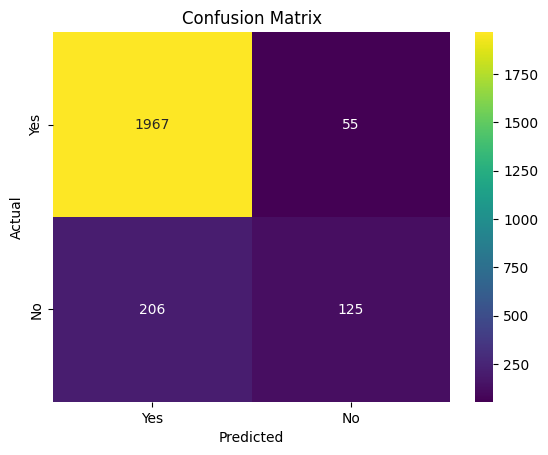

In [49]:
sns.heatmap(con_mat,
           annot=True, 
           fmt= 'd', 
           cmap="viridis", 
           xticklabels=["Yes", "No"], 
           yticklabels=["Yes", "No"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Model performance

High True Positives (1967): The model performs  good at identifying individuals who have bank accounts.

The model incorrectly predicted that 55 individuals who have a bank account when they actually do.

Low True Negatives: The model struggles to correctly  identify  individuals without bank accounts with 125

High False Positives: The model mistakenly predicts some individuals having bank account when they don't actually have one.

## insights

1. Influence of Country-Specific elements: Cultural norms, financial infrastructure, and economic growth are among the elements that are shown to have a major impact on the variations in bank account ownership among nations. Kenya's higher banking penetration is probably a result of its robust financial sector, pro-financial inclusion legislation (such laws governing mobile money and financial literacy initiatives), and higher rates of urbanization. On the other hand, previous political unrest, economic circumstances, and the growth of the banking sector in Rwanda, Tanzania, and Uganda may all have an impact on the unfavorable correlations shown there. 

2. Given that urban areas often have superior banking infrastructure than rural ones, the significant association between bank account ownership and urban residency emphasizes the significance of having physical access to financial institutions. 

3. The positive relationship between bank account ownership and mobile phone access indicates that digital financial services and mobile banking are essential for increasing financial access. 

4. The relationship between job type and bank account ownership highlights the importance of employment status and income stability on financial access, as people in formal employment (private sector, self-employed) are more likely to own a bank account. 

While these correlations show relationships, they do not prove causality. Disparities in financial inclusion could be caused by additional underlying causes. Although this study offers insightful information about banking patterns in Kenya, Rwanda, Tanzania, and Uganda, more investigation is required to fully comprehend the dynamics of financial inclusion.


## Testing

In [51]:
df_Test['bank_account'] = model.predict(test_set)

In [53]:
submission = pd.DataFrame({"uniqueid": df_Test["uniqueid"] + " x " + df_Test["country"],
                           "bank_account": df_Test.bank_account})

In [ ]:
submission

In [ ]:
submission.sample(5)

In [ ]:
pd.read_csv('SampleSubmission.csv')

In [57]:
submission.to_csv('first_submission.csv', index = False)